In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings 
warnings.filterwarnings('ignore')

sns.set() 

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12, 6 
plt.rcParams['font.size'] = 14 
plt.rcParams['axes.unicode_minus'] = False 

# 결측치 시각화를 위한 라이브러리
import missingno 

# 데이터 전처리 알고리즘 
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import StandardScaler 

# 학습용과 검증용으로 나누는  함수 
from sklearn.model_selection import train_test_split 

# 교차검증 
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한도구 
from sklearn.model_selection import GridSearchCV 

# 머신러닝 알고리즘 - 분류 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import AdaBoostClassifier 
from sklearn.ensemble import GradientBoostingClassifier 
from lightgbm import LGBMClassifier 
from xgboost import XGBClassifier 
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀 
from sklearn.neighbors import KNeighborsRegressor 
from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import Ridge 
from sklearn.linear_model import Lasso 
from sklearn.linear_model import ElasticNet 
from sklearn.svm import SVR 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor 
from sklearn.ensemble import GradientBoostingRegressor 
from lightgbm import LGBMRegressor 
from xgboost import XGBRegressor 
from sklearn.ensemble import VotingRegressor 

# 학습 모델 저장을 위한 라이브러리
import pickle 

In [135]:
# 학습이 완료된 모델을 저장할 파일 이름
best_model_path = "C:/Users/SAMSUNG/OneDrive/바탕 화면/방법1/dat"
# 교차검증 횟수
cv_count = 10
# 교차 검증
kfold = KFold(n_splits=cv_count, shuffle=True, random_state=1)
# 평가 결과를 담을 리스트
# 필요하다면 다른 것도 만들어주세요
f1_score_list = []
# 학습 모델 이름
model_name_list = []

데이터준비

In [ ]:
# 데이터준비
train_df = pd.read_parquet(r"C:\Users\SAMSUNG\OneDrive\바탕 화면\방법1\ab_train29 (2).parquet")
test_df = pd.read_parquet(r"C:\Users\SAMSUNG\OneDrive\바탕 화면\방법1\ab_test.parquet")

display(train_df.columns)
display(test_df.columns)

Index(['ID', '기준년월', 'Segment', '이용후경과월_할부_무이자', '이용후경과월_할부',
       '이용개월수_할부_무이자_R12M', '이용개월수_할부_R12M', '카드이용한도금액_B2M', '카드이용한도금액_B1M',
       '카드이용한도금액', '이용개월수_할부_R6M', 'CA한도금액', '이용개월수_할부_무이자_R6M',
       '이용개월수_할부_R3M', '이용개월수_할부_무이자_R3M', '이용건수_할부_무이자_R3M', '이용건수_할부_R3M',
       '이용금액_할부_무이자_R6M', '방문횟수_앱_R6M', '거주시도명', 'RV전환가능여부', '연령',
       'Life_Stage', '인입횟수_ARS_R6M', '캠페인접촉건수_R12M', '이용메뉴건수_ARS_R6M',
       '대표청구서수령지구분코드', '청구서수령방법', '캠페인접촉일수_R12M', '방문일수_PC_R6M', '방문횟수_PC_R6M',
       '할인건수_R3M'],
      dtype='object')

Index(['ID', '기준년월', '이용후경과월_할부_무이자', '이용후경과월_할부', '이용개월수_할부_무이자_R12M',
       '이용개월수_할부_R12M', '카드이용한도금액_B2M', '카드이용한도금액_B1M', '카드이용한도금액',
       '이용개월수_할부_R6M', 'CA한도금액', '이용개월수_할부_무이자_R6M', '이용개월수_할부_R3M',
       '이용개월수_할부_무이자_R3M', '이용건수_할부_무이자_R3M', '이용건수_할부_R3M', '이용금액_할부_무이자_R6M',
       '방문횟수_앱_R6M', '거주시도명', 'RV전환가능여부', '연령', 'Life_Stage', '인입횟수_ARS_R6M',
       '캠페인접촉건수_R12M', '이용메뉴건수_ARS_R6M', '대표청구서수령지구분코드', '청구서수령방법',
       '캠페인접촉일수_R12M', '방문일수_PC_R6M', '방문횟수_PC_R6M', '할인건수_R3M'],
      dtype='object')

In [137]:
# 두 데이터 프레임을 합친다.
all_df = pd.concat([train_df, test_df])
all_df.reset_index(inplace=True, drop=True)

In [138]:
# ID 기준년월 뺴기
all_df.drop('기준년월', axis=1, inplace=True)

In [139]:
# ID 기준년월 뺴기
all_df.drop('ID', axis=1, inplace=True)

In [140]:
all_df

,Segment,이용후경과월_할부_무이자,이용후경과월_할부,이용개월수_할부_무이자_R12M,이용개월수_할부_R12M,카드이용한도금액_B2M,카드이용한도금액_B1M,카드이용한도금액,이용개월수_할부_R6M,CA한도금액,...,Life_Stage,인입횟수_ARS_R6M,캠페인접촉건수_R12M,이용메뉴건수_ARS_R6M,대표청구서수령지구분코드,청구서수령방법,캠페인접촉일수_R12M,방문일수_PC_R6M,방문횟수_PC_R6M,할인건수_R3M
0,A,0,0,9,10,224182,206178,207389,6,57536,...,자녀성장(1),10회 이상,5회 이상,10회 이상,우편,우편,5일 이상,1회 이상,1회 이상,1회 이상
1,A,0,0,9,11,206178,207915,212983,6,57577,...,자녀성장(1),10회 이상,5회 이상,10회 이상,우편,우편,5일 이상,1회 이상,1회 이상,1회 이상
2,A,0,0,9,11,207915,212331,217163,6,59388,...,자녀성장(1),10회 이상,5회 이상,10회 이상,우편,우편,5일 이상,1회 이상,1회 이상,1회 이상
3,A,0,0,9,11,212331,225457,205333,6,61378,...,자녀성장(1),10회 이상,5회 이상,10회 이상,우편,우편,5일 이상,1회 이상,1회 이상,1회 이상
4,A,0,0,9,11,225457,217014,215143,6,59595,...,자녀성장(1),10회 이상,5회 이상,10회 이상,우편,우편,5일 이상,1회 이상,1회 이상,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
601111,NaN,12,12,0,0,0,0,0,0,0,...,노년생활,1회 이상,1회 이상,1회 이상,우편,우편,1일 이상,1회 이상,1회 이상,1회 이상
601112,NaN,12,12,0,0,49990,50008,49025,0,17876,...,자녀출산기,1회 이상,1회 이상,1회 이상,우편,우편,1일 이상,1회 이상,1회 이상,1회 이상
601113,NaN,12,12,0,0,30004,30011,29996,0,13332,...,자녀성장(1),1회 이상,1회 이상,1회 이상,이메일,이메일,1일 이상,1회 이상,1회 이상,1회 이상
601114,NaN,2,2,3,3,37139,37999,42610,1,17362,...,가족구축기,1회 이상,5회 이상,1회 이상,K톡명세서+이메일,K톡,5일 이상,1회 이상,1회 이상,1회 이상


In [141]:
# 문자열 -> 숫자

Segment_encoder = LabelEncoder()
방문횟수_앱_R6M_encoder = LabelEncoder()
거주시도명_encoder = LabelEncoder()
RV전환가능여부_encoder = LabelEncoder()
연령_encoder = LabelEncoder()
Life_Stage_encoder = LabelEncoder()
인입횟수_ARS_R6M_encoder = LabelEncoder()
캠페인접촉건수_R12M_encoder = LabelEncoder()
이용메뉴건수_ARS_R6M_encoder = LabelEncoder()
대표청구서수령지구분코드_encoder = LabelEncoder()
청구서수령방법_encoder = LabelEncoder()
캠페인접촉일수_R12M_encoder = LabelEncoder()
방문일수_PC_R6M_encoder = LabelEncoder()
방문횟수_PC_R6M_encoder = LabelEncoder()
할인건수_R3M_encoder = LabelEncoder()

Segment_encoder.fit(all_df['Segment'])
방문횟수_앱_R6M_encoder.fit(all_df['방문횟수_앱_R6M'])
거주시도명_encoder.fit(all_df['거주시도명'])
RV전환가능여부_encoder.fit(all_df['RV전환가능여부'])
연령_encoder.fit(all_df['연령'])
Life_Stage_encoder.fit(all_df['Life_Stage'])
인입횟수_ARS_R6M_encoder.fit(all_df['인입횟수_ARS_R6M'])
캠페인접촉건수_R12M_encoder.fit(all_df['캠페인접촉건수_R12M'])
이용메뉴건수_ARS_R6M_encoder.fit(all_df['이용메뉴건수_ARS_R6M'])
대표청구서수령지구분코드_encoder.fit(all_df['대표청구서수령지구분코드'])
청구서수령방법_encoder.fit(all_df['청구서수령방법'])
캠페인접촉일수_R12M_encoder.fit(all_df['캠페인접촉일수_R12M'])
방문일수_PC_R6M_encoder.fit(all_df['방문일수_PC_R6M'])
방문횟수_PC_R6M_encoder.fit(all_df['방문횟수_PC_R6M'])
할인건수_R3M_encoder.fit(all_df['할인건수_R3M'])


all_df['Segment'] = Segment_encoder.transform(all_df['Segment'])
all_df['방문횟수_앱_R6M'] = 방문횟수_앱_R6M_encoder.transform(all_df['방문횟수_앱_R6M'])
all_df['거주시도명'] = 거주시도명_encoder.transform(all_df['거주시도명'])
all_df['RV전환가능여부'] = RV전환가능여부_encoder.transform(all_df['RV전환가능여부'])
all_df['연령'] = 연령_encoder.transform(all_df['연령'])
all_df['Life_Stage'] = Life_Stage_encoder.transform(all_df['Life_Stage'])
all_df['인입횟수_ARS_R6M'] = 인입횟수_ARS_R6M_encoder.transform(all_df['인입횟수_ARS_R6M'])
all_df['캠페인접촉건수_R12M'] = 캠페인접촉건수_R12M_encoder.transform(all_df['캠페인접촉건수_R12M'])
all_df['이용메뉴건수_ARS_R6M'] = 이용메뉴건수_ARS_R6M_encoder.transform(all_df['이용메뉴건수_ARS_R6M'])
all_df['대표청구서수령지구분코드'] = 대표청구서수령지구분코드_encoder.transform(all_df['대표청구서수령지구분코드'])
all_df['청구서수령방법'] = 청구서수령방법_encoder.transform(all_df['청구서수령방법'])
all_df['캠페인접촉일수_R12M'] = 캠페인접촉일수_R12M_encoder.transform(all_df['캠페인접촉일수_R12M'])
all_df['방문일수_PC_R6M'] = 방문일수_PC_R6M_encoder.transform(all_df['방문일수_PC_R6M'])
all_df['방문횟수_PC_R6M'] = 방문횟수_PC_R6M_encoder.transform(all_df['방문횟수_PC_R6M'])
all_df['할인건수_R3M'] = 할인건수_R3M_encoder.transform(all_df['할인건수_R3M'])


all_df

,Segment,이용후경과월_할부_무이자,이용후경과월_할부,이용개월수_할부_무이자_R12M,이용개월수_할부_R12M,카드이용한도금액_B2M,카드이용한도금액_B1M,카드이용한도금액,이용개월수_할부_R6M,CA한도금액,...,Life_Stage,인입횟수_ARS_R6M,캠페인접촉건수_R12M,이용메뉴건수_ARS_R6M,대표청구서수령지구분코드,청구서수령방법,캠페인접촉일수_R12M,방문일수_PC_R6M,방문횟수_PC_R6M,할인건수_R3M
0,0,0,0,9,10,224182,206178,207389,6,57536,...,4,0,5,0,4,4,4,1,1,1
1,0,0,0,9,11,206178,207915,212983,6,57577,...,4,0,5,0,4,4,4,1,1,1
2,0,0,0,9,11,207915,212331,217163,6,59388,...,4,0,5,0,4,4,4,1,1,1
3,0,0,0,9,11,212331,225457,205333,6,61378,...,4,0,5,0,4,4,4,1,1,1
4,0,0,0,9,11,225457,217014,215143,6,59595,...,4,0,5,0,4,4,4,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
601111,2,12,12,0,0,0,0,0,0,0,...,1,1,2,1,4,4,2,1,1,1
601112,2,12,12,0,0,49990,50008,49025,0,17876,...,6,1,2,1,4,4,2,1,1,1
601113,2,12,12,0,0,30004,30011,29996,0,13332,...,4,1,2,1,5,5,2,1,1,1
601114,2,2,2,3,3,37139,37999,42610,1,17362,...,0,1,5,1,0,0,4,1,1,1


In [186]:
all_df['Segment'].value_counts()

Segment
2    600000
0       972
1       144
Name: count, dtype: int64

In [151]:
# 표준화를 위해 결과데이터를 제외한다.
X = all_df.drop('Segment', axis=1)
# 표준화
scaler1 = StandardScaler()
scaler1.fit(X)

,copy,True
,with_mean,True
,with_std,True


In [153]:
# 입력과 결과로 나눈다.
X = train_df.drop('Segment', axis=1)
y = train_df['Segment']


In [154]:
# 문자열 -> 숫자
y = Segment_encoder.transform(y)
X['방문횟수_앱_R6M'] = 방문횟수_앱_R6M_encoder.transform(X['방문횟수_앱_R6M'])
X['거주시도명'] = 거주시도명_encoder.transform(X['거주시도명'])
X['RV전환가능여부'] = RV전환가능여부_encoder.transform(X['RV전환가능여부'])
X['연령'] = 연령_encoder.transform(X['연령'])
X['Life_Stage'] = Life_Stage_encoder.transform(X['Life_Stage'])
X['인입횟수_ARS_R6M'] = 인입횟수_ARS_R6M_encoder.transform(X['인입횟수_ARS_R6M'])
X['캠페인접촉건수_R12M'] = 캠페인접촉건수_R12M_encoder.transform(X['캠페인접촉건수_R12M'])
X['이용메뉴건수_ARS_R6M'] = 이용메뉴건수_ARS_R6M_encoder.transform(X['이용메뉴건수_ARS_R6M'])
X['대표청구서수령지구분코드'] = 대표청구서수령지구분코드_encoder.transform(X['대표청구서수령지구분코드'])
X['청구서수령방법'] = 청구서수령방법_encoder.transform(X['청구서수령방법'])
X['캠페인접촉일수_R12M'] = 캠페인접촉일수_R12M_encoder.transform(X['캠페인접촉일수_R12M'])
X['방문일수_PC_R6M'] = 방문일수_PC_R6M_encoder.transform(X['방문일수_PC_R6M'])
X['방문횟수_PC_R6M'] = 방문횟수_PC_R6M_encoder.transform(X['방문횟수_PC_R6M'])
X['할인건수_R3M'] = 할인건수_R3M_encoder.transform(X['할인건수_R3M'])
X


,ID,기준년월,이용후경과월_할부_무이자,이용후경과월_할부,이용개월수_할부_무이자_R12M,이용개월수_할부_R12M,카드이용한도금액_B2M,카드이용한도금액_B1M,카드이용한도금액,이용개월수_할부_R6M,...,Life_Stage,인입횟수_ARS_R6M,캠페인접촉건수_R12M,이용메뉴건수_ARS_R6M,대표청구서수령지구분코드,청구서수령방법,캠페인접촉일수_R12M,방문일수_PC_R6M,방문횟수_PC_R6M,할인건수_R3M
0,TRAIN_002898,201807,0,0,9,10,224182,206178,207389,6,...,4,0,5,0,4,4,4,1,1,1
1,TRAIN_002898,201808,0,0,9,11,206178,207915,212983,6,...,4,0,5,0,4,4,4,1,1,1
2,TRAIN_002898,201809,0,0,9,11,207915,212331,217163,6,...,4,0,5,0,4,4,4,1,1,1
3,TRAIN_002898,201810,0,0,9,11,212331,225457,205333,6,...,4,0,5,0,4,4,4,1,1,1
4,TRAIN_002898,201811,0,0,9,11,225457,217014,215143,6,...,4,0,5,0,4,4,4,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,TRAIN_393888,201808,1,1,1,0,199138,188564,193187,1,...,4,1,2,1,4,4,2,1,1,1
1112,TRAIN_393888,201809,3,3,1,1,188564,182821,202844,1,...,4,1,2,1,4,4,2,1,1,1
1113,TRAIN_393888,201810,4,4,1,1,182821,194226,181936,1,...,4,1,2,1,4,4,2,1,1,1
1114,TRAIN_393888,201811,4,4,1,1,194226,182110,185479,1,...,4,1,2,1,4,4,2,1,1,1


In [155]:
X.drop('ID', axis=1, inplace=True)

In [156]:
X.drop('기준년월', axis=1, inplace=True)

In [157]:
X


,이용후경과월_할부_무이자,이용후경과월_할부,이용개월수_할부_무이자_R12M,이용개월수_할부_R12M,카드이용한도금액_B2M,카드이용한도금액_B1M,카드이용한도금액,이용개월수_할부_R6M,CA한도금액,이용개월수_할부_무이자_R6M,...,Life_Stage,인입횟수_ARS_R6M,캠페인접촉건수_R12M,이용메뉴건수_ARS_R6M,대표청구서수령지구분코드,청구서수령방법,캠페인접촉일수_R12M,방문일수_PC_R6M,방문횟수_PC_R6M,할인건수_R3M
0,0,0,9,10,224182,206178,207389,6,57536,6,...,4,0,5,0,4,4,4,1,1,1
1,0,0,9,11,206178,207915,212983,6,57577,6,...,4,0,5,0,4,4,4,1,1,1
2,0,0,9,11,207915,212331,217163,6,59388,6,...,4,0,5,0,4,4,4,1,1,1
3,0,0,9,11,212331,225457,205333,6,61378,6,...,4,0,5,0,4,4,4,1,1,1
4,0,0,9,11,225457,217014,215143,6,59595,6,...,4,0,5,0,4,4,4,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,1,1,1,0,199138,188564,193187,1,58925,1,...,4,1,2,1,4,4,2,1,1,1
1112,3,3,1,1,188564,182821,202844,1,54946,1,...,4,1,2,1,4,4,2,1,1,1
1113,4,4,1,1,182821,194226,181936,1,54095,1,...,4,1,2,1,4,4,2,1,1,1
1114,4,4,1,1,194226,182110,185479,1,56475,1,...,4,1,2,1,4,4,2,1,1,1


In [158]:
# 표준화
X = scaler1.transform(X)
X

array([[-1.89134494, -1.76988966,  3.11859484, ...,  0.06320153,
        -0.09441986,  0.15252693],
       [-1.89134494, -1.76988966,  3.11859484, ...,  0.06320153,
        -0.09441986,  0.15252693],
       [-1.89134494, -1.76988966,  3.11859484, ...,  0.06320153,
        -0.09441986,  0.15252693],
       ...,
       [-1.00174632, -0.90273343, -0.2071384 , ...,  0.06320153,
        -0.09441986,  0.15252693],
       [-1.00174632, -0.90273343, -0.2071384 , ...,  0.06320153,
        -0.09441986,  0.15252693],
       [-0.77934667, -0.68594437, -0.2071384 , ...,  0.06320153,
        -0.09441986,  0.15252693]])

In [159]:
train_X = X
train_y = y

기본모델 사용하기

In [160]:
# XGBoost
xgboost_basic_model = XGBClassifier(verbose=-1, silent=True)
# 교차 검증을 수행한다
r1 = cross_val_score(xgboost_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("XGBoost Basic")

In [161]:
# LGBM
lgbm_basic_model = LGBMClassifier(verbose=-1)
# 교차 검증을 수행한다
r1 = cross_val_score(lgbm_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("LGBM Basic")

In [162]:
# HardVoting 구성

temp_model1 = LGBMClassifier(verbose=-1)
temp_model2 = XGBClassifier(verbose=-1, silent=True)

hard_voting_model_list = [
    ('model1', temp_model1),
    ('model2', temp_model2),
]

hard_voting_basic_model = VotingClassifier(estimators=hard_voting_model_list, voting='hard')

# 교차 검증을 수행한다
r1 = cross_val_score(hard_voting_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("HardVoting Basic")

In [163]:
# SoftVoting 구성

temp_model1 = LGBMClassifier(verbose=-1)
temp_model2 = XGBClassifier(verbose=-1, silent=True)

soft_voting_model_list = [
    ('model1', temp_model1),
    ('model2', temp_model2),
]

soft_voting_basic_model = VotingClassifier(estimators=soft_voting_model_list, voting='soft')

# 교차 검증을 수행한다
r1 = cross_val_score(soft_voting_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("SoftVoting Basic")

In [164]:
f1_score_list

[0.974002574002574, 0.9793758043758043, 0.9748954311454311, 0.9793838481338479]

하이퍼 파라미터 

In [165]:
# LGBM
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

temp_model = LGBMClassifier(verbose=-1)
lgbm_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
lgbm_grid_clf.fit(train_X, train_y)

# 평가 결과를 담아준다.
f1_score_list.append(lgbm_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("LGBM Tuning")

In [166]:
# XGBoost
params = {
    'booster' : ['gbtree', 'gblinear'],
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

temp_model = XGBClassifier(verbose=-1, silent=True)
xgboost_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
xgboost_grid_clf.fit(train_X, train_y)

# 평가 결과를 담아준다.
f1_score_list.append(xgboost_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("XGBoost Tuning")

In [167]:
# HardVoting 구성
temp_model1 = LGBMClassifier(verbose=-1)
temp_model2 = XGBClassifier(verbose=-1, silent=True)

# 하이퍼 파라미터 셋팅
temp_model1.set_params(**lgbm_grid_clf.best_params_)
temp_model2.set_params(**xgboost_grid_clf.best_params_)

hard_voting_model_list = [
    ('model1', temp_model1),
    ('model2', temp_model2),
]

hard_voting_tuning_model = VotingClassifier(estimators=hard_voting_model_list, voting='hard')

# 교차 검증을 수행한다
r1 = cross_val_score(hard_voting_tuning_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("HardVoting Tuning")

In [168]:
# SoftVoting 구성
temp_model1 = LGBMClassifier(verbose=-1)
temp_model2 = XGBClassifier(verbose=-1, silent=True)

# 하이퍼 파라미터 셋팅
temp_model1.set_params(**lgbm_grid_clf.best_params_)
temp_model2.set_params(**xgboost_grid_clf.best_params_)

soft_voting_model_list = [
    ('model1', temp_model1),
    ('model2', temp_model2),
]

soft_voting_tuning_model = VotingClassifier(estimators=soft_voting_model_list, voting='soft')

# 교차 검증을 수행한다
r1 = cross_val_score(soft_voting_tuning_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("SoftVoting Tuning")

In [170]:
d1 = {
    'f1_micro score' : f1_score_list
}
result_df = pd.DataFrame(d1, index=model_name_list)
result_df.sort_values(by='f1_micro score', ascending=False, inplace=True)
result_df

,f1_micro score
LGBM Tuning,0.981170
SoftVoting Tuning,0.980277
SoftVoting Basic,0.979384
LGBM Basic,0.979376
XGBoost Tuning,0.975804
HardVoting Basic,0.974895
HardVoting Tuning,0.974011
XGBoost Basic,0.974003


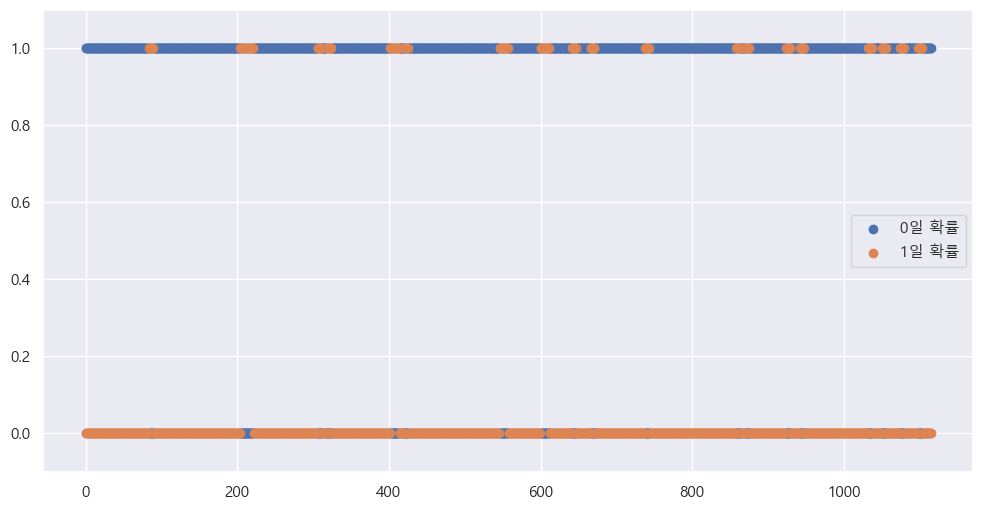

In [171]:
# 예측 결과에 대한 확률 값을 가져온다
proba_a1 = lgbm_grid_clf.best_estimator_.predict_proba(train_X)
# 0일 확률
a10 = proba_a1[:, 0]
# 1일 확률
a20 = proba_a1[:, 1]

plt.scatter(list(range(len(a10))), a10, label='0일 확률')
plt.scatter(list(range(len(a20))), a20, label='1일 확률')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.show()

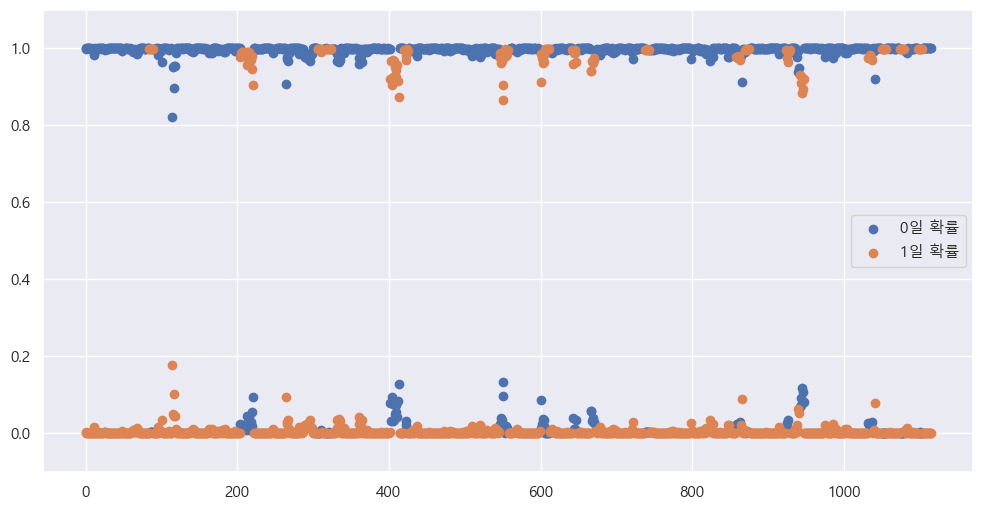

In [172]:
# 예측 결과에 대한 확률 값을 가져온다
proba_a1 = xgboost_grid_clf.best_estimator_.predict_proba(train_X)
# 0일 확률
a10 = proba_a1[:, 0]
# 1일 확률
a20 = proba_a1[:, 1]

plt.scatter(list(range(len(a10))), a10, label='0일 확률')
plt.scatter(list(range(len(a20))), a20, label='1일 확률')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.show()

In [174]:
# 최종 모델을 생성하고 전체 데이터를 학습 시킨다.
best_model = LGBMClassifier()
best_model.set_params(**lgbm_grid_clf.best_params_)
best_model.fit(train_X, train_y)
best_model

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [176]:
encoders = {
    'Segment': Segment_encoder,
    '방문횟수_앱_R6M': 방문횟수_앱_R6M_encoder,
    '거주시도명': 거주시도명_encoder,
    'RV전환가능여부': RV전환가능여부_encoder,
    '연령': 연령_encoder,
    'Life_Stage': Life_Stage_encoder,
    '인입횟수_ARS_R6M': 인입횟수_ARS_R6M_encoder,
    '캠페인접촉건수_R12M': 캠페인접촉건수_R12M_encoder,
    '이용메뉴건수_ARS_R6M': 이용메뉴건수_ARS_R6M_encoder,
    '대표청구서수령지구분코드': 대표청구서수령지구분코드_encoder,
    '청구서수령방법': 청구서수령방법_encoder,
    '캠페인접촉일수_R12M': 캠페인접촉일수_R12M_encoder,
    '방문일수_PC_R6M': 방문일수_PC_R6M_encoder,
    '방문횟수_PC_R6M': 방문횟수_PC_R6M_encoder,
    '할인건수_R3M': 할인건수_R3M_encoder
}

In [178]:
# 학습 모델 등을 저장한다.
with open(best_model_path, 'wb') as fp :
    pickle.dump(best_model, fp)
    pickle.dump(encoders, fp)
    pickle.dump(scaler1, fp)

print('저장완료')

저장완료


In [179]:
# 저장 확인
with open(best_model_path, 'rb') as fp :
    test_model = pickle.load(fp)
    test_encoders = pickle.load(fp)
    test_scaler1 = pickle.load(fp)

In [180]:
r1 = test_model.predict(train_X)
r2 = f1_score(train_y, r1)
r2

1.0

In [192]:
# 학습용과 예측용으로 데이터를 다시 나눈다.
train_df = all_df.query('Segment in [0, 1]')
test_df = all_df.query('Segment == 2')
test_df.drop('Segment', axis=1, inplace=True)

train_df.reset_index(inplace=True, drop=True)
test_df.reset_index(inplace=True, drop=True)

display(train_df.isna().sum())
display(test_df.isna().sum())

Segment              0
이용후경과월_할부_무이자        0
이용후경과월_할부            0
이용개월수_할부_무이자_R12M    0
이용개월수_할부_R12M        0
카드이용한도금액_B2M         0
카드이용한도금액_B1M         0
카드이용한도금액             0
이용개월수_할부_R6M         0
CA한도금액               0
이용개월수_할부_무이자_R6M     0
이용개월수_할부_R3M         0
이용개월수_할부_무이자_R3M     0
이용건수_할부_무이자_R3M      0
이용건수_할부_R3M          0
이용금액_할부_무이자_R6M      0
방문횟수_앱_R6M           0
거주시도명                0
RV전환가능여부             0
연령                   0
Life_Stage           0
인입횟수_ARS_R6M         0
캠페인접촉건수_R12M         0
이용메뉴건수_ARS_R6M       0
대표청구서수령지구분코드         0
청구서수령방법              0
캠페인접촉일수_R12M         0
방문일수_PC_R6M          0
방문횟수_PC_R6M          0
할인건수_R3M             0
dtype: int64

이용후경과월_할부_무이자        0
이용후경과월_할부            0
이용개월수_할부_무이자_R12M    0
이용개월수_할부_R12M        0
카드이용한도금액_B2M         0
카드이용한도금액_B1M         0
카드이용한도금액             0
이용개월수_할부_R6M         0
CA한도금액               0
이용개월수_할부_무이자_R6M     0
이용개월수_할부_R3M         0
이용개월수_할부_무이자_R3M     0
이용건수_할부_무이자_R3M      0
이용건수_할부_R3M          0
이용금액_할부_무이자_R6M      0
방문횟수_앱_R6M           0
거주시도명                0
RV전환가능여부             0
연령                   0
Life_Stage           0
인입횟수_ARS_R6M         0
캠페인접촉건수_R12M         0
이용메뉴건수_ARS_R6M       0
대표청구서수령지구분코드         0
청구서수령방법              0
캠페인접촉일수_R12M         0
방문일수_PC_R6M          0
방문횟수_PC_R6M          0
할인건수_R3M             0
dtype: int64

In [193]:
test_df

,이용후경과월_할부_무이자,이용후경과월_할부,이용개월수_할부_무이자_R12M,이용개월수_할부_R12M,카드이용한도금액_B2M,카드이용한도금액_B1M,카드이용한도금액,이용개월수_할부_R6M,CA한도금액,이용개월수_할부_무이자_R6M,...,Life_Stage,인입횟수_ARS_R6M,캠페인접촉건수_R12M,이용메뉴건수_ARS_R6M,대표청구서수령지구분코드,청구서수령방법,캠페인접촉일수_R12M,방문일수_PC_R6M,방문횟수_PC_R6M,할인건수_R3M
0,12,12,0,0,50006,49999,50902,0,18131,0,...,4,1,2,1,5,5,2,1,1,1
1,0,0,9,10,50003,50000,50080,6,16819,6,...,3,1,5,1,2,2,4,1,1,1
2,3,1,5,7,100056,100053,100045,3,30505,1,...,4,1,0,1,5,5,0,1,1,1
3,2,2,1,2,19693,21035,18508,1,6402,1,...,4,1,1,1,4,4,1,1,1,1
4,0,0,6,7,3924,4291,4033,4,0,4,...,4,1,2,1,4,4,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,12,12,0,0,0,0,0,0,0,0,...,1,1,2,1,4,4,2,1,1,1
599996,12,12,0,0,49990,50008,49025,0,17876,0,...,6,1,2,1,4,4,2,1,1,1
599997,12,12,0,0,30004,30011,29996,0,13332,0,...,4,1,2,1,5,5,2,1,1,1
599998,2,2,3,3,37139,37999,42610,1,17362,1,...,0,1,5,1,0,0,4,1,1,1


In [196]:
train_df

,Segment,이용후경과월_할부_무이자,이용후경과월_할부,이용개월수_할부_무이자_R12M,이용개월수_할부_R12M,카드이용한도금액_B2M,카드이용한도금액_B1M,카드이용한도금액,이용개월수_할부_R6M,CA한도금액,...,Life_Stage,인입횟수_ARS_R6M,캠페인접촉건수_R12M,이용메뉴건수_ARS_R6M,대표청구서수령지구분코드,청구서수령방법,캠페인접촉일수_R12M,방문일수_PC_R6M,방문횟수_PC_R6M,할인건수_R3M
0,0,0,0,9,10,224182,206178,207389,6,57536,...,4,0,5,0,4,4,4,1,1,1
1,0,0,0,9,11,206178,207915,212983,6,57577,...,4,0,5,0,4,4,4,1,1,1
2,0,0,0,9,11,207915,212331,217163,6,59388,...,4,0,5,0,4,4,4,1,1,1
3,0,0,0,9,11,212331,225457,205333,6,61378,...,4,0,5,0,4,4,4,1,1,1
4,0,0,0,9,11,225457,217014,215143,6,59595,...,4,0,5,0,4,4,4,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,0,1,1,1,0,199138,188564,193187,1,58925,...,4,1,2,1,4,4,2,1,1,1
1112,0,3,3,1,1,188564,182821,202844,1,54946,...,4,1,2,1,4,4,2,1,1,1
1113,0,4,4,1,1,182821,194226,181936,1,54095,...,4,1,2,1,4,4,2,1,1,1
1114,0,4,4,1,1,194226,182110,185479,1,56475,...,4,1,2,1,4,4,2,1,1,1


In [199]:
# 처리가 완료된 데이터를 저장한다.
train_df.to_parquet("C:/Users/SAMSUNG/OneDrive/바탕 화면/ab/train_df_29.parquet", index=False)
test_df.to_parquet("C:/Users/SAMSUNG/OneDrive/바탕 화면/ab/test_df_29.parquet", index=False)